# scSVC defines fine-grained subtypes of TAM cells

## Notebook Guide

**Purpose.** Analyze Monocyte sc-SVC states, marker programs, enrichment results, and cell-cell communication.

**Inputs.** Executed Monocyte reconstruction outputs under `../../output/sc_SVC_case/P1CRC_Xenium/Monocyte/` plus raw Xenium data for comparison.

**Outputs.** Spatial maps, marker dot plots, volcano plots, enrichment figures, and communication summaries saved under the Monocyte output directory and displayed inline.

**Reading order.**
1. Load reconstructed SVCs
2. Visualize spatial subtypes and marker programs
3. Compare sc-SVC and raw Xenium differential signals
4. Run CellPhoneDB communication analysis

**Reproducibility note.** `revise` imports are standard package imports from the installed `revise-svc` distribution; this notebook does not modify `sys.path` to import the repository source tree.


In [1]:
import os
os.environ.setdefault("TQDM_DISABLE", "1")
os.environ.setdefault("TQDM_MININTERVAL", "60")

try:
    from IPython import get_ipython
    _ipython = get_ipython()
    if _ipython is not None:
        _ipython.run_line_magic("matplotlib", "inline")
except Exception:
    pass

output_dir = "../../output/sc_SVC_case/P2CRC_Xenium"
select_ct = "Mono_Macro"

## Load Reconstructed SVCs

Load the executed reconstruction outputs that drive the downstream figures.


In [2]:
import os
import scanpy as sc

from revise.backend.runners.sc_svc_application import ScSVCAnalysis
import pandas as pd
try:
    import gseapy as gp
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError('Install pathway dependencies with pip install \"revise-svc[pathway]\"') from exc
import revise.analysis.bio as _revise_bio

_EMPTY_ENRICHMENT_COLUMNS = [
    "Gene_set",
    "Term",
    "Overlap",
    "P-value",
    "Adjusted P-value",
    "Old P-value",
    "Old Adjusted P-value",
    "Odds Ratio",
    "Combined Score",
    "Genes",
]

def _get_enrichment_human_compatible(deg_genes, geneset_file, cutoff=0.05):
    if not deg_genes:
        return pd.DataFrame(columns=_EMPTY_ENRICHMENT_COLUMNS)
    try:
        enr = gp.enrichr(
            gene_list=deg_genes,
            gene_sets=geneset_file,
            organism="human",
            cutoff=cutoff,
        )
        return enr.results
    except Exception as exc:
        print(f"Skipping enrichment analysis: {type(exc).__name__}: {exc}")
        return pd.DataFrame(columns=_EMPTY_ENRICHMENT_COLUMNS)

_revise_bio.get_enrichment = _get_enrichment_human_compatible


svc_save_dir = f"{output_dir}/{select_ct}"
sc_svc_expr = sc.read_h5ad(f"{svc_save_dir}/sc_SVC_expr.h5ad")
sc_svc_spatial = sc.read_h5ad(f"{svc_save_dir}/sc_SVC_spatial.h5ad")

sc_svc_analysis = ScSVCAnalysis(sc_svc_spatial, sc_svc_expr,
                            "SVC_cluster")
# Legacy notebooks use these aliases in downstream result and plotting cells.
sc_SVC_adata = sc_svc_analysis.sc_SVC_adata_spatial.copy()
adata_sp = sc_svc_analysis.sc_SVC_adata_spatial.copy()
adata_sc = sc_svc_analysis.sc_SVC_adata_expr.copy()


/cpfs01/projects-HDD/cfff-c7cd658afc74_HDD/jiaoyifeng/miniconda3/envs/brainbeacon/lib/python3.9/site-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


Conducting differential expression analysis...


In [3]:
cm_df = sc_svc_analysis.get_cm_df("Level2")
cm_df

/cpfs01/projects-HDD/cfff-c7cd658afc74_HDD/jiaoyifeng/miniconda3/envs/brainbeacon/lib/python3.9/site-packages/revise/backend/runners/sc_svc_application.py:67: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = self.sc_SVC_adata_expr.obs.groupby([self.cluster_col, sub_cell_type_col]).size()


Level2,Macro_C1QC,Macro_MKI67,Macro_SPP1,Mono
SVC_cluster,,,,
0,305,36,14,6
1,142,17,19,3
2,812,17,6,24
3,438,5,24,15
4,122,17,157,16
5,390,6,6,6
6,244,3,3,248
7,101,8,7,288


/tmp/ipykernel_31481/2691602389.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', lut=10)


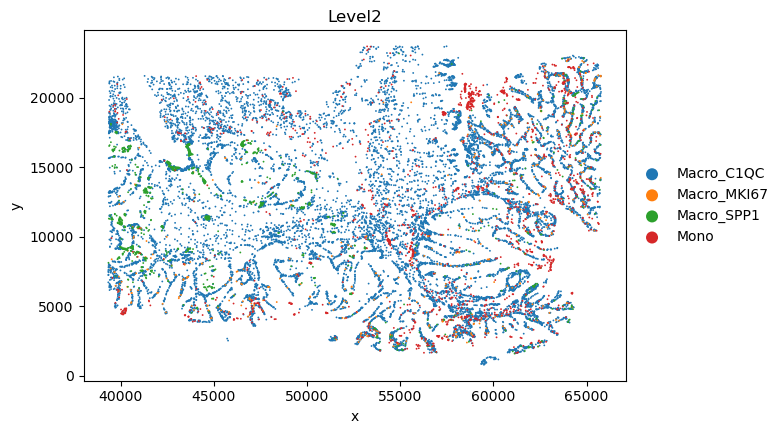

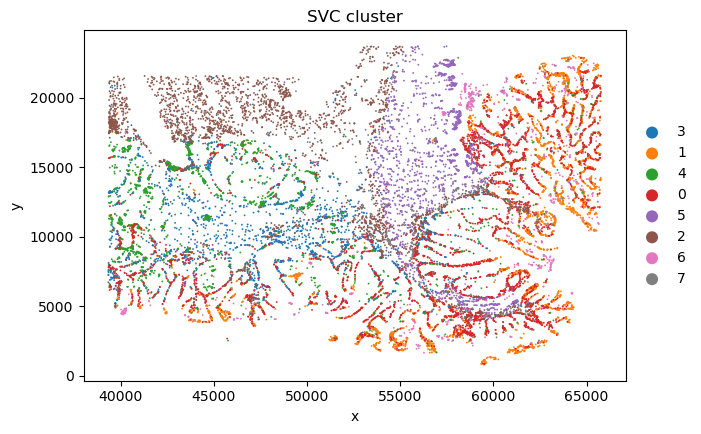

In [4]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors 

size = None
cmap = plt.cm.get_cmap('tab20', lut=10)
palette = [mcolors.to_hex(cmap(i)) for i in range(cmap.N)]

sc.pl.scatter(sc_svc_analysis.sc_SVC_adata_spatial, x="x", y="y",
              color='Level2',
              size=size)
desired_order = ['3','1','4','0','5','2','6','7'] # for better visualization
current_categories = sc_svc_analysis.sc_SVC_adata_spatial.obs['SVC_cluster'].cat.categories.astype(str).tolist()
ordered_categories = [cat for cat in desired_order if cat in current_categories]
ordered_categories += [cat for cat in current_categories if cat not in ordered_categories]
sc_svc_analysis.sc_SVC_adata_spatial.obs['SVC_cluster'] = (
    sc_svc_analysis.sc_SVC_adata_spatial.obs['SVC_cluster'].cat.reorder_categories(ordered_categories, ordered=True)
)
sc.pl.scatter(sc_svc_analysis.sc_SVC_adata_spatial, x="x", y="y",
              color='SVC_cluster',
              size=size)

## Spatial Subtype Maps

Display reconstructed spatial cell states and side-by-side annotation comparisons.


<Figure size 1000x800 with 0 Axes>

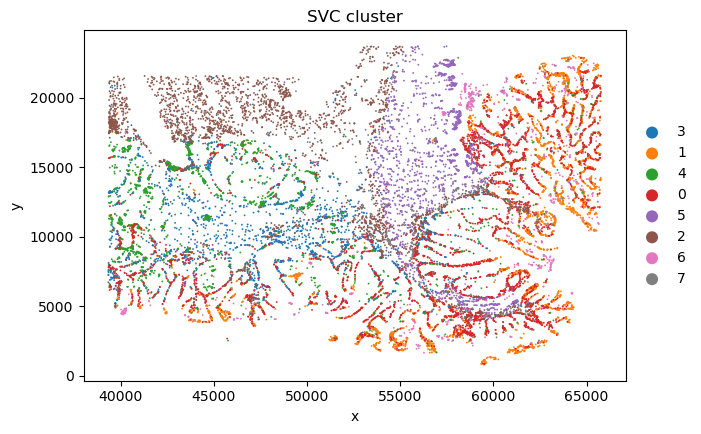

<Figure size 1000x1600 with 0 Axes>

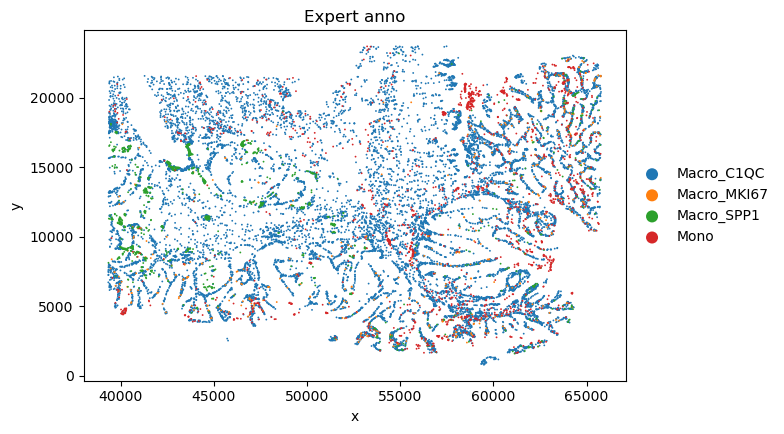

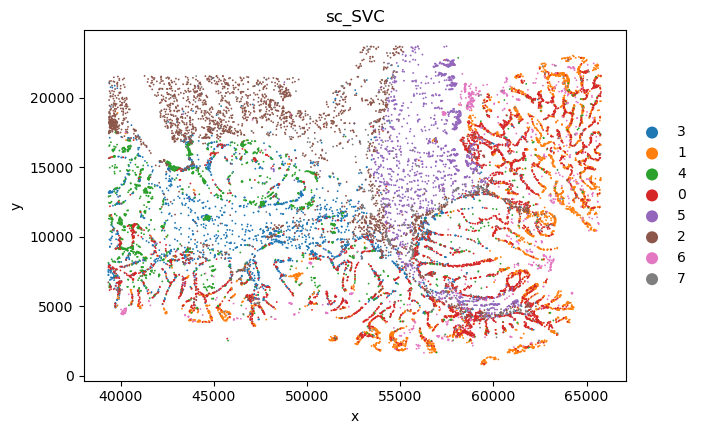

In [5]:
import matplotlib.pyplot as plt
def plot_sc_SVC(adata, color, title = None, file_name = None):

    colors = color if isinstance(color, (list, tuple)) else [color]
    titles = title if isinstance(title, (list, tuple)) else [title] * len(colors)
    plt.figure(figsize=(10, 8*len(colors)))
    for color_key, plot_title in zip(colors, titles):
        sc.pl.scatter(
            adata, x="x", y="y",
            color=color_key,
            title=plot_title, show=False,
        )
    plt.savefig(file_name, dpi = 300)
    plt.show()
    plt.close()

sc_SVC_file_name = f"{output_dir}/sc_SVC.png"
plot_sc_SVC(sc_svc_analysis.sc_SVC_adata_spatial, color='SVC_cluster',
            file_name=sc_SVC_file_name
            )

sc_SVC_file_name = f"{output_dir}/compare.png"
plot_sc_SVC(sc_svc_analysis.sc_SVC_adata_spatial, color=['Level2','SVC_cluster'],
            title=["Expert anno", "sc_SVC"],
            file_name=sc_SVC_file_name
            )

## bioinfo analysis

In [6]:
sc_svc_analysis.sc_SVC_degs.to_csv(f"{output_dir}/degs_all.csv")
sc_svc_analysis.sc_SVC_degs

,group,gene,logfoldchanges,pvals,pvals_adj,log_q
0,0,MMP12,6.157999,1.990059e-136,2.604590e-132,100.0
1,2,C1QB,2.797948,1.100504e-165,1.440340e-161,100.0
2,6,CTSZ,-3.827421,1.739724e-142,9.487292e-140,100.0
3,6,GPNMB,-4.479141,2.049615e-184,2.235447e-181,100.0
4,6,CD4,-3.998396,1.025762e-164,8.390732e-162,100.0
...,...,...,...,...,...,...
104699,2,SPHK2,-0.000144,9.998170e-01,1.000000e+00,-0.0
104700,2,NSMCE3,-0.000513,9.987000e-01,1.000000e+00,-0.0
104701,2,PRKCQ,-0.001938,9.986947e-01,1.000000e+00,-0.0
104702,2,THOC6,-0.000487,9.986390e-01,1.000000e+00,-0.0


In [7]:
fc_threshold = 1
pathway_num = 20
gene_num = 60
geneset_file = ["MSigDB_Hallmark_2020"]
# geneset_file = ["MSigDB_Hallmark_2020"]
pathway_file_name = f"{output_dir}/pathway_{fc_threshold}_{pathway_num}.txt"
cluster_nums = ['0', '1', '4']
all_pathway = sc_svc_analysis.get_pathway_conclusion(
    cluster_nums, fc_threshold=fc_threshold, pathway_num=pathway_num, gene_num=gene_num, geneset_file=geneset_file, normalize=False)
all_pathway.to_csv(pathway_file_name)
all_pathway

Conducting differential expression analysis...


Cluster 4: 
Up-regulated genes: ['SPP1', 'APOE', 'VIM', 'CHI3L1', 'CD9', 'CSTB', 'FBP1', 'GPNMB', 'FN1', 'APOC1', 'FTL', 'CD52', 'FTH1', 'LSP1', 'S100A6', 'SDC2', 'LGALS1', 'LPL', 'MARCO', 'NUPR1', 'S100A10', 'ANXA2', 'TIMP2', 'ANPEP', 'CTSK', 'APLP2', 'S100A11', 'LGALS3', 'OLR1', 'AQP9', 'CYP27A1', 'SPARC', 'ITGA5', 'GCHFR', 'NCF2', 'RGCC', 'RNASE1', 'FABP5', 'MMP7', 'EMP3', 'APOC2', 'S100A4', 'TSPO', 'CHIT1', 'CD82', 'LIPA', 'PLAUR', 'ITGB3', 'VAT1', 'EMP1', 'ZNF385A', 'COL6A2', 'S100A9', 'GLIPR2', 'SH3BGRL3', 'CD109', 'TREM2', 'FAM20C', 'SLC11A1', 'LTA4H']
Enriched pathways: ['Coagulation' 'Epithelial Mesenchymal Transition' 'Complement'
 'Cholesterol Homeostasis' 'Inflammatory Response' 'Angiogenesis'
 'Hypoxia' 'Apoptosis' 'Xenobiotic Metabolism' 'p53 Pathway'
 'KRAS Signaling Up' 'Reactive Oxygen Species Pathway' 'UV Response Dn'
 'IL-2/STAT5 Signaling' 'Adipogenesis' 'Estrogen Response Late'
 'Myogenesis' 'mTORC1 Signaling' 'IL-6/JAK/STAT3 Signaling'
 'Bile Acid Metabolism']



Cluster 0: 
Up-regulated genes: ['STAB1', 'MS4A6A', 'C1QC', 'MPEG1', 'MMP12', 'C1QB', 'SELENOP', 'C1QA', 'CD74', 'FGL2', 'CTSC', 'SLCO2B1', 'CD14', 'ENPP2', 'TMEM176B', 'SLC40A1', 'ITPR2', 'CYBB', 'CSF1R', 'FCGRT', 'DNASE1L3', 'GPR34', 'ITM2B', 'TGFBI', 'AXL', 'SIGLEC12', 'SGPL1', 'CD4', 'ADAM28', 'FUCA1', 'TMEM176A', 'ITGA4', 'FPR3', 'LPAR6', 'SIGLEC10', 'OLFML2B', 'MERTK', 'FOLR2', 'CD163L1', 'ITGA9', 'NRP1', 'CD93', 'CD209', 'CD300A', 'GIMAP7', 'AOAH', 'ADAP2', 'ARHGAP4', 'C3AR1', 'OTULINL', 'FRMD4A', 'ST8SIA4', 'SERPINF1', 'CIITA', 'CD163', 'P2RY13', 'P2RY6', 'PLAU', 'GAL3ST4', 'MS4A4A']
Enriched pathways: ['KRAS Signaling Up' 'Inflammatory Response' 'Interferon Gamma Response'
 'Complement' 'Allograft Rejection' 'Apical Junction'
 'IL-6/JAK/STAT3 Signaling' 'Interferon Alpha Response'
 'Androgen Response' 'Coagulation' 'Glycolysis'
 'Epithelial Mesenchymal Transition' 'mTORC1 Signaling' 'Angiogenesis'
 'Hedgehog Signaling' 'IL-2/STAT5 Signaling' 'Protein Secretion'
 'PI3K/AKT/mTOR

Cluster 1: 
Up-regulated genes: ['IL7R', 'CXCL10', 'CXCL9', 'IL4I1', 'ADAM19', 'CXCL8', 'GBP1', 'IDO1', 'C15orf48', 'MARCKSL1', 'LCN2', 'SOD2', 'CXCL1', 'GBP5', 'GPR183', 'IL1B', 'SLC39A8', 'MMP12', 'RNF19B', 'SOCS3', 'SERPINB9', 'CD40', 'CXCL11', 'CALHM6', 'PSTPIP2', 'CD80', 'CXCL3', 'MT2A', 'LYN', 'ACSL5', 'LAMP3', 'IER3', 'GPR132', 'EHD1', 'NKG7', 'APOL3', 'WARS', 'UBD', 'MYO1G', 'EDEM1', 'EDEM2', 'SRSF7', 'DAPP1', 'MAP3K7', 'LYSMD2', 'TRAF1', 'AP3D1', 'CDK4', 'TIFAB', 'EXOC7', 'SCO2', 'CLEC4D', 'PA2G4', 'NCL', 'NLRC5', 'CD274', 'SUCO', 'IL32', 'SRSF5', 'TNFAIP3']
Enriched pathways: ['TNF-alpha Signaling via NF-kB' 'Interferon Gamma Response'
 'Inflammatory Response' 'IL-6/JAK/STAT3 Signaling' 'Allograft Rejection'
 'Complement' 'KRAS Signaling Up' 'IL-2/STAT5 Signaling'
 'Epithelial Mesenchymal Transition' 'Interferon Alpha Response'
 'PI3K/AKT/mTOR  Signaling' 'Apoptosis' 'Myc Targets V2' 'G2-M Checkpoint'
 'Myc Targets V1' 'Hypoxia' 'Pperoxisome' 'Fatty Acid Metabolism'
 'UV Resp

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes,group
0,MSigDB_Hallmark_2020,Coagulation,10/138,9.883841e-12,2.119033e-10,0,0,30.956250,784.435086,SPARC;MMP7;ITGB3;CTSK;APOC2;APOC1;FN1;OLR1;CD9...,4
1,MSigDB_Hallmark_2020,Epithelial Mesenchymal Transition,11/200,1.695226e-11,2.119033e-10,0,0,23.459778,581.817027,SPARC;LGALS1;ITGB3;ANPEP;COL6A2;PLAUR;SPP1;FN1...,4
2,MSigDB_Hallmark_2020,Complement,9/200,7.945171e-09,6.620976e-08,0,0,18.246689,340.313554,LGALS3;APOC1;TIMP2;PLAUR;FN1;OLR1;LTA4H;LIPA;S...,4
3,MSigDB_Hallmark_2020,Cholesterol Homeostasis,6/74,8.918131e-08,5.573832e-07,0,0,32.470588,527.081887,LGALS3;FABP5;PLAUR;LPL;CD9;S100A11,4
4,MSigDB_Hallmark_2020,Inflammatory Response,8/200,1.424605e-07,7.123026e-07,0,0,15.823718,249.448268,MARCO;CD82;ITGB3;AQP9;PLAUR;OLR1;EMP3;ITGA5,4
...,...,...,...,...,...,...,...,...,...,...,...
27,MSigDB_Hallmark_2020,Bile Acid Metabolism,1/112,2.864074e-01,3.184112e-01,0,0,3.027791,3.785768,ACSL5,1
28,MSigDB_Hallmark_2020,Unfolded Protein Response,1/113,2.885602e-01,3.184112e-01,0,0,3.000605,3.729307,EDEM1,1
30,MSigDB_Hallmark_2020,Glycolysis,1/200,4.533326e-01,4.533326e-01,0,0,1.681373,1.330183,IER3,1
29,MSigDB_Hallmark_2020,Xenobiotic Metabolism,1/200,4.533326e-01,4.533326e-01,0,0,1.681373,1.330183,MT2A,1


## Marker And Differential Programs

Summarize marker genes, differential genes, and pathway-level signals.


Conducting differential expression analysis...


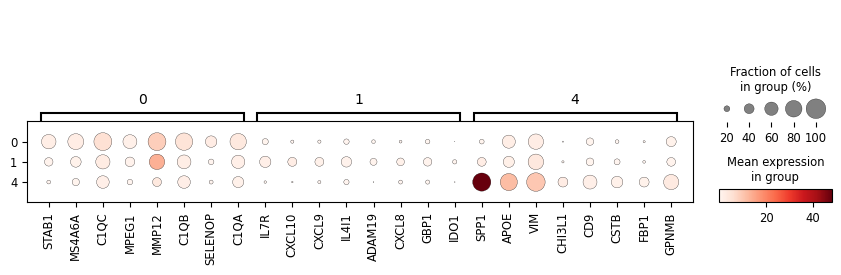

In [8]:
cluster_nums = ['0', '1', '4']

degs = sc_svc_analysis.get_svc_degs(cluster_nums, 1)

marker_dict = (
    degs.groupby('group')['gene']
    .apply(lambda x: x.head(8).tolist())
    .to_dict()
)
sc_svc_analysis.get_dot_plot(cluster_nums, marker_dict)

<Figure size 800x600 with 0 Axes>

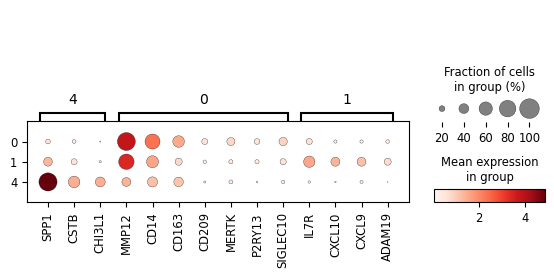

<Figure size 640x480 with 0 Axes>

In [9]:
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.useafm'] = False
plt.figure(figsize=(8, 6))

marker_dict = {
    '4': ['SPP1', 'CSTB', 'CHI3L1'], 
    '0': [
        'MMP12', 
        'CD14',      
        'CD163',     
        'CD209',     
        'MERTK',     
        'P2RY13',    
        'SIGLEC10',  
    ],
    '1': [
        'IL7R', 
        'CXCL10', 
        'CXCL9', 
        'ADAM19' 
    ]
}

sc_svc_analysis.get_dot_plot(cluster_nums, marker_dict, normalize=True)
plt.savefig(f"{output_dir}/sc_SVC_dotplot.pdf", dpi=300, bbox_inches='tight')
plt.show()
plt.close()

### sc_SVC

In [10]:
tumor_cluster_num = '1'  # Inflammation
tumor_cluster_num = '0'  # Regulation

normal_cluster = '5'  # Normal

if tumor_cluster_num == '1':
    tumor_cluster = 'Inflammation'
elif tumor_cluster_num == '0':
    tumor_cluster = 'Regulation'

/cpfs01/projects-HDD/cfff-c7cd658afc74_HDD/jiaoyifeng/miniconda3/envs/brainbeacon/lib/python3.9/site-packages/revise/backend/runners/sc_svc_application.py:134: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  select_adata.obs['SVC_cluster'].replace(replace_cols, inplace=True)
/cpfs01/projects-HDD/cfff-c7cd658afc74_HDD/jiaoyifeng/miniconda3/envs/brainbeacon/lib/python3.9/site-packages/revise/backend/runners/sc_svc_application.py:134: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is dep

Conducting differential expression analysis...


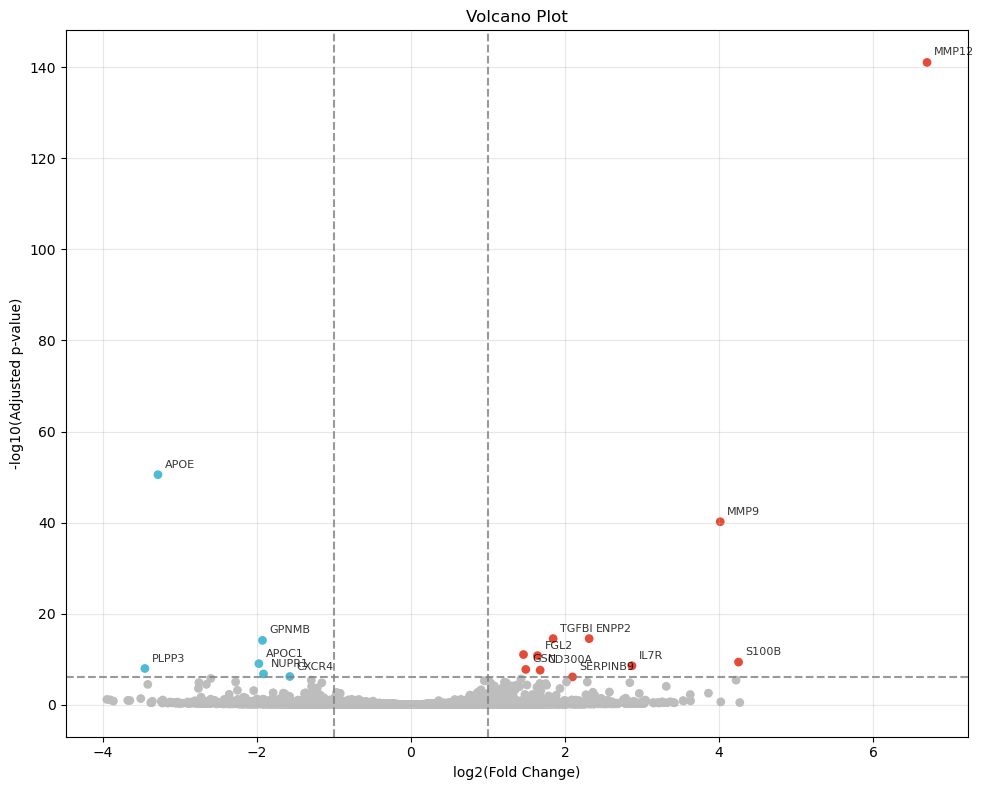

<Figure size 640x480 with 0 Axes>

In [11]:
cluster_nums = [normal_cluster, tumor_cluster_num]
replace_cols = {normal_cluster: 'Normal-infiltrated', tumor_cluster_num: 'Tumor-infiltrated'}
degs = sc_svc_analysis.get_volcano_plot(cluster_nums, target_group="Tumor-infiltrated", replace_cols=replace_cols, fc_threshold=None, log_fold_changes=10, logfc_threshold=1, padj_threshold=1e-6, top_k=10)
plt.savefig(f"{output_dir}/sc_SVC/{tumor_cluster}_volcano.pdf", dpi=300, bbox_inches='tight')
plt.show()


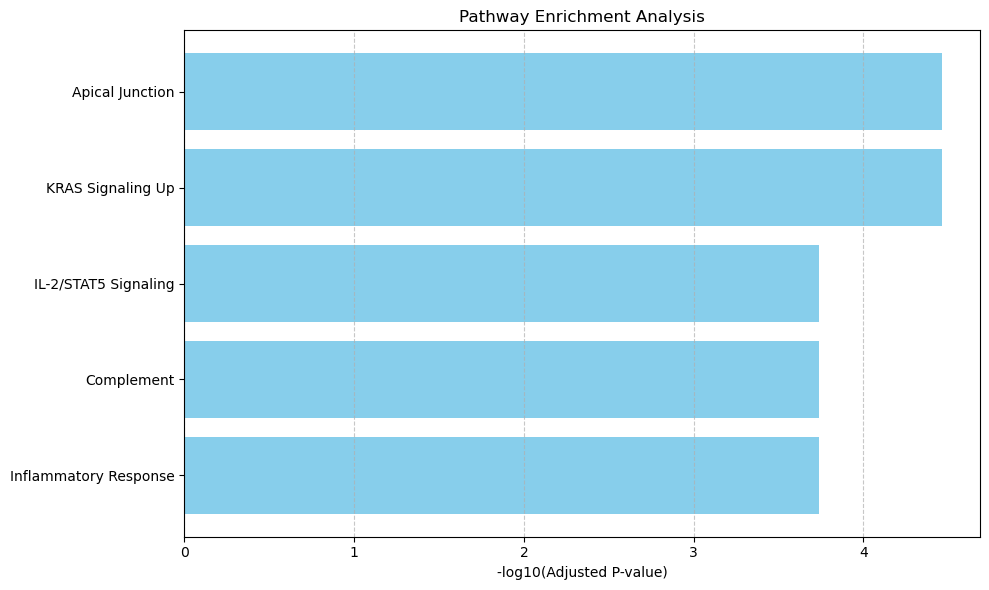

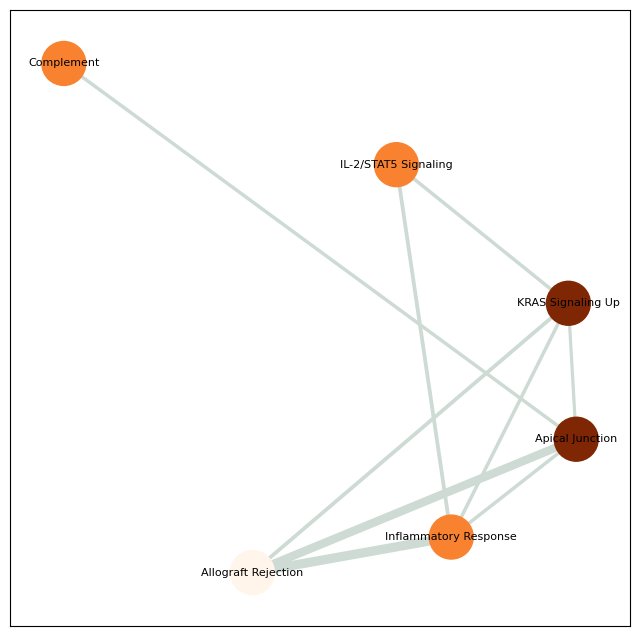

In [12]:
# for enrichment analysis
from revise.analysis.bio import get_enrichment, pathway_barplot, pathway_network_plot

degs = degs[degs['logfoldchanges'] > 0]
degs.reset_index(drop = True, inplace = True)
deg_genes = degs["gene"][:60].tolist()
pathway = get_enrichment(deg_genes, geneset_file)
pathway.to_csv(f"{output_dir}/sc_SVC/{tumor_cluster}_pathway.csv", index=False)

pathway_barplot(pathway)
pathway_network_plot(pathway, 
                     top_term = 6, 
                     save_file_name = f'{output_dir}/sc_SVC/{tumor_cluster}_network.pdf')




### raw

/tmp/ipykernel_31481/1060215734.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  raw_select_adata.obs['SVC_cluster'].replace({normal_cluster: 'Normal-infiltrated', tumor_cluster_num: 'Tumor-infiltrated'}, inplace=True)
/tmp/ipykernel_31481/1060215734.py:5: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  raw_select_

Conducting differential expression analysis...


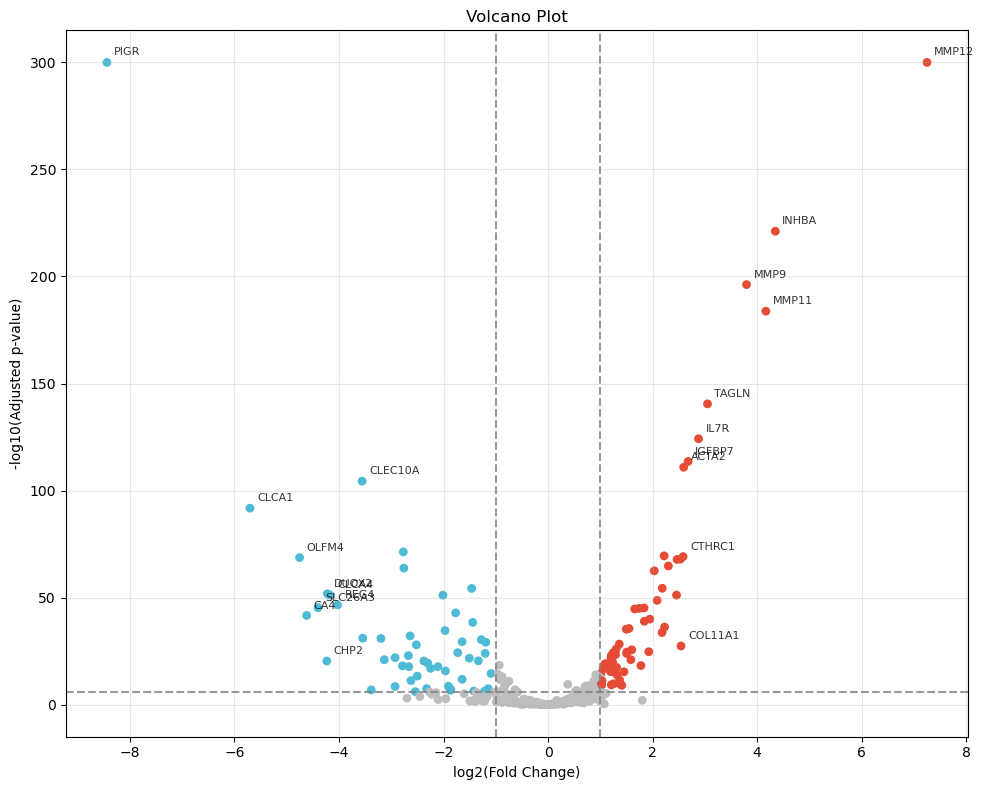

In [13]:
from revise.analysis.bio import get_degs
os.makedirs(f"{output_dir}/raw_Xenium", exist_ok=True)
sc_SVC_adata = sc_svc_analysis.sc_SVC_adata_spatial.copy()
raw_select_adata = sc_SVC_adata[sc_SVC_adata.obs['SVC_cluster'].isin([normal_cluster, tumor_cluster_num])]
raw_select_adata.obs['SVC_cluster'].replace({normal_cluster: 'Normal-infiltrated', tumor_cluster_num: 'Tumor-infiltrated'}, inplace=True)
raw_deg_df = get_degs(raw_select_adata, groupby='SVC_cluster', method='t-test', fc_threshold=None)
raw_deg_df = raw_deg_df[raw_deg_df['group'] == "Tumor-infiltrated"]
raw_deg_df.reset_index(drop = True, inplace = True)
raw_deg_df.to_csv(f"{output_dir}/raw_Xenium/{tumor_cluster}_degs.csv", index=False)

# raw_deg_df = raw_deg_df[raw_deg_df['logfoldchanges'].abs() <= 10]
from revise.analysis.bio import plot_volcano
plot_volcano(raw_deg_df, logfc_threshold=1, padj_threshold=1e-6, 
                 top_k=10, save_file_name = f"{output_dir}/raw_Xenium/{tumor_cluster}_volcano.pdf")


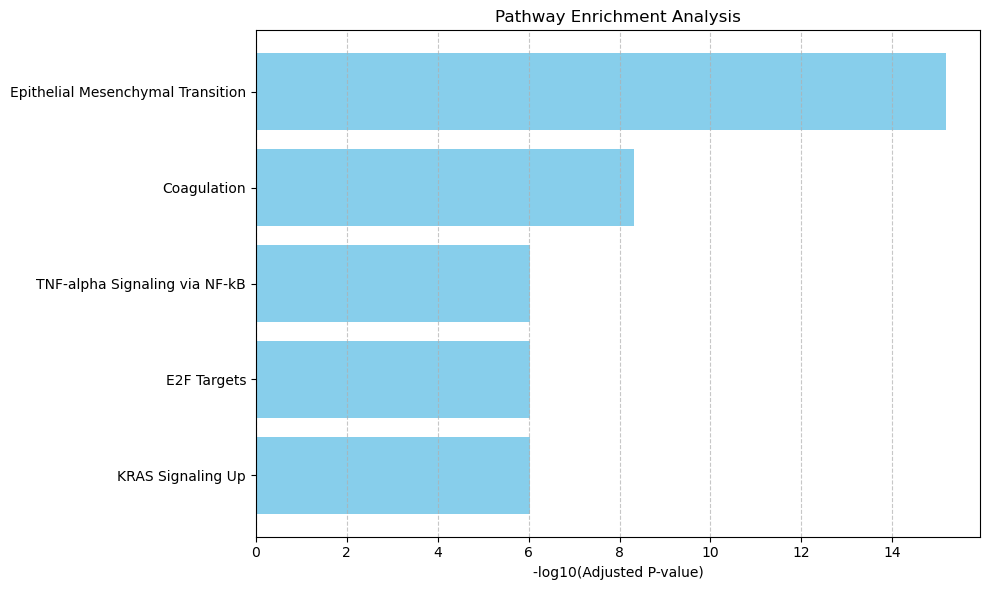

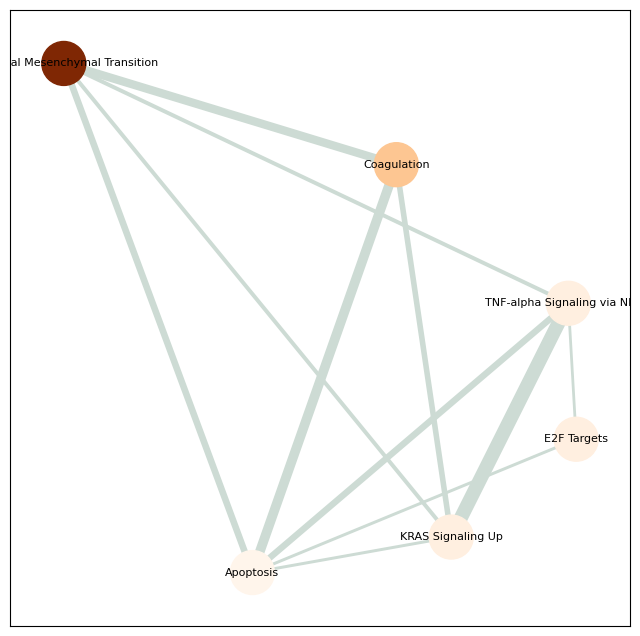

In [14]:
# for enrichment analysis
from revise.analysis.bio import get_enrichment
raw_deg_df = raw_deg_df[raw_deg_df['logfoldchanges'] > 0] # postive for up-regulated pathway
raw_deg_df.reset_index(drop = True, inplace = True)
deg_genes = raw_deg_df["gene"][:60].tolist()
pathway = get_enrichment(deg_genes, geneset_file)
pathway.to_csv(f"{output_dir}/raw_Xenium/{tumor_cluster}_pathway.csv", index=False)

pathway_barplot(pathway)
pathway_network_plot(pathway, 
                     top_term = 6, 
                     save_file_name = f'{output_dir}/raw_Xenium/{tumor_cluster}_network.pdf')

## CCI

In [15]:
output_dir

'../../output/sc_SVC_case/P2CRC_Xenium'

In [16]:

import scanpy as sc

T_SVC_adata = sc.read(f"{output_dir}/../T/sc_SVC_expr.h5ad")
T_SVC_adata = T_SVC_adata[T_SVC_adata.obs['SVC_cluster'].isin(['1','5'])]
# T_SVC_adata = T_SVC_adata[T_SVC_adata.obs['SVC_cluster'].isin(['0','1','5'])]

T_SVC_adata.obs['SVC_cluster'] = [f"T_{i}" for i in T_SVC_adata.obs['SVC_cluster']]

TAM_SVC_adata = sc.read(f"{output_dir}/sc_SVC_expr.h5ad")
TAM_SVC_adata = TAM_SVC_adata[TAM_SVC_adata.obs['SVC_cluster'].isin(['0','1'])]
TAM_SVC_adata.obs['SVC_cluster'] = [f"TAM_{i}" for i in TAM_SVC_adata.obs['SVC_cluster']]

adata = T_SVC_adata.concatenate(TAM_SVC_adata)
adata

/tmp/ipykernel_31481/3388971096.py:7: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  T_SVC_adata.obs['SVC_cluster'] = [f"T_{i}" for i in T_SVC_adata.obs['SVC_cluster']]
/tmp/ipykernel_31481/3388971096.py:11: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  TAM_SVC_adata.obs['SVC_cluster'] = [f"TAM_{i}" for i in TAM_SVC_adata.obs['SVC_cluster']]
/tmp/ipykernel_31481/3388971096.py:13: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata = T_SVC_adata.concatenate(TAM_SVC_adata)


AnnData object with n_obs × n_vars = 1763 × 13088
    obs: 'Level1', 'Level2', 'SVC_cluster', 'max_score', 'batch'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells'
    obsm: 'SVC_cluster'

In [17]:
adata.obs['SVC_cluster'].value_counts()


SVC_cluster
T_5      857
TAM_1    345
T_1      287
TAM_0    274
Name: count, dtype: int64

In [18]:
celltype_key = "SVC_cluster"
from pathlib import Path
try:
    import omicverse as ov
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError('Install CCI dependencies with pip install \"revise-svc[cci]\"') from exc
try:
    import cellphonedb as _cellphonedb
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError('Install CCI dependencies with pip install \"revise-svc[cci]\"') from exc
cpdb_path = Path('./CCI/cellphonedb.zip')
if not cpdb_path.is_file():
    raise FileNotFoundError(f'CellPhoneDB data asset is missing: {cpdb_path}')
cpdb_results, adata_cpdb = ov.single.run_cellphonedb_v5(
    adata,
    cpdb_file_path=str(cpdb_path),  
    celltype_key=celltype_key,
    min_cell_fraction=0.005,             
    min_genes=200,                       
    min_cells=3,                         
    iterations=1000,                     
    threshold=0.1,                       
    pvalue=0.05,                         
    threads=10,                          
    output_dir=f'{output_dir}/cpdb_results',         
    cleanup_temp=True                    
)

🔬 Starting CellPhoneDB analysis...
✅ Valid CellPhoneDB database found: ./CCI/cellphonedb.zip (0.1 MB)
   - Original data: 1763 cells, 13088 genes
   - Cell types passing 0.5% threshold: 4
   - Minimum cells required: 8
   - After filtering: 1763 cells, 13088 genes
   - After preprocessing: 1763 cells, 12470 genes
   - Temporary directory: /tmp/cpdb_temp_hxatwp5o
   - Output directory: ../../output/sc_SVC_case/P2CRC_Xenium/cpdb_results


   - Created temporary input files
   - Running CellPhoneDB statistical analysis...


Reading user files...


The following user files were loaded successfully:
/tmp/cpdb_temp_hxatwp5o/counts_matrix.h5ad
/tmp/cpdb_temp_hxatwp5o/metadata.tsv
[ ][CORE][13/05/26-10:39:31][INFO] [Cluster Statistical Analysis] Threshold:0.1 Iterations:1000 Debug-seed:42 Threads:10 Precision:3


[ ][CORE][13/05/26-10:39:31][WARNING] Debug random seed enabled. Set to 42


...

[ ][CORE][13/05/26-10:41:00][INFO] Building results


[ ][CORE][13/05/26-10:41:00][INFO] Scoring interactions: Filtering genes per cell type..


[ ][CORE][13/05/26-10:41:00][INFO] Scoring interactions: Calculating mean expression of each gene per group/cell type..


[ ][CORE][13/05/26-10:41:00][INFO] Scoring interactions: Calculating scores for all interactions and cell types..


Saved deconvoluted to ../../output/sc_SVC_case/P2CRC_Xenium/cpdb_results/statistical_analysis_deconvoluted_05_13_2026_104112.txt
Saved deconvoluted_percents to ../../output/sc_SVC_case/P2CRC_Xenium/cpdb_results/statistical_analysis_deconvoluted_percents_05_13_2026_104112.txt
Saved means to ../../output/sc_SVC_case/P2CRC_Xenium/cpdb_results/statistical_analysis_means_05_13_2026_104112.txt
Saved pvalues to ../../output/sc_SVC_case/P2CRC_Xenium/cpdb_results/statistical_analysis_pvalues_05_13_2026_104112.txt
Saved significant_means to ../../output/sc_SVC_case/P2CRC_Xenium/cpdb_results/statistical_analysis_significant_means_05_13_2026_104112.txt
Saved interaction_scores to ../../output/sc_SVC_case/P2CRC_Xenium/cpdb_results/statistical_analysis_interaction_scores_05_13_2026_104112.txt
   - CellPhoneDB analysis completed successfully!
   - Formatting results for visualization...
   - Found 13 info columns and 16 cell type pairs
   - Found 84 pathway classifications
   - Created visualization 

In [19]:
cpdb_results.keys()

dict_keys(['deconvoluted', 'deconvoluted_percents', 'means', 'pvalues', 'significant_means', 'CellSign_active_interactions', 'CellSign_active_interactions_deconvoluted', 'interaction_scores'])

In [20]:
select_clusters = ['T_5','TAM_0']
df = cpdb_results['significant_means']
df = cpdb_results['interaction_scores']
df
# df = df[(df['source'].isin(select_clusters)) & (df['target'].isin(select_clusters))]
# df_sorted = df.sort_values('mean', ascending=False)
# df_sorted

,id_cp_interaction,interacting_pair,partner_a,partner_b,gene_a,gene_b,secreted,receptor_a,receptor_b,annotation_strategy,...,TAM_1|T_1,TAM_1|T_5,T_1|TAM_0,T_1|TAM_1,T_1|T_1,T_1|T_5,T_5|TAM_0,T_5|TAM_1,T_5|T_1,T_5|T_5
0,CPI-SC0A2DB962D,CDH1_integrin_a2b1_complex,simple:P12830,complex:integrin_a2b1_complex,CDH1,NaN,False,False,False,curated,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,CPI-SC0B5CEA47D,COL10A1_integrin_a2b1_complex,simple:Q03692,complex:integrin_a2b1_complex,COL10A1,NaN,True,False,False,curated,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,CPI-SC0C8B7BCBB,COL11A1_integrin_a2b1_complex,simple:P12107,complex:integrin_a2b1_complex,COL11A1,NaN,True,False,False,curated,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,CPI-SC0B86B7CED,COL12A1_integrin_a2b1_complex,simple:Q99715,complex:integrin_a2b1_complex,COL12A1,NaN,True,False,False,curated,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,CPI-SC0FA343CEF,COL13A1_integrin_a2b1_complex,simple:Q5TAT6,complex:integrin_a2b1_complex,COL13A1,NaN,False,False,False,curated,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2897,CPI-CS09A35DD21,Prostacyclin_byPTGIS_PTGIR,complex:Prostacyclin_byPTGIS,simple:P43119,NaN,PTGIR,True,False,True,curated,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2898,CPI-SS0CBC7840D,PTPRC_CD22,simple:P08575,simple:P20273,PTPRC,CD22,False,False,True,curated,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2899,CPI-SS0822AEF5F,PTPRC_MRC1,simple:P08575,simple:P22897,PTPRC,MRC1,False,False,True,curated,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2900,CPI-SS096F8C268,PTPRD_IL1RAP,simple:P23468,simple:Q9NPH3,PTPRD,IL1RAP,True,True,True,curated,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [21]:
cpdb_results.keys()
deconvoluted_percents = cpdb_results['deconvoluted_percents']

In [22]:
select_LR_pairs = [
    'ANXA1_FPR3','LTB_LTBR',
    'CXCL10_CXCR3','CXCL9_CXCR3', 
    'CCL5_CCR1',
]

In [23]:
def filter_df_by_cell_groups(df, cell_groups):
    df.dropna(subset=['gene_a', 'gene_b'], inplace=True)
    df['LR_pair'] = df['gene_a'] + '_' + df['gene_b']
    df.set_index('LR_pair', inplace=True)
    
    pattern = '|'.join(cell_groups)
    result_df = df[
               df.columns[df.columns.str.contains(pattern)].tolist()
               ]

    return result_df


cell_groups = adata.obs['SVC_cluster'].unique().tolist()
print(cell_groups)

pvals = cpdb_results['pvalues']
pvals = filter_df_by_cell_groups(pvals, cell_groups)
pvals = pvals.loc[select_LR_pairs] 

# significant_means
significant_means = cpdb_results['significant_means']
significant_means = filter_df_by_cell_groups(significant_means, cell_groups)
significant_means = significant_means.loc[select_LR_pairs] 

interaction_scores = cpdb_results['interaction_scores']
interaction_scores = filter_df_by_cell_groups(interaction_scores, cell_groups)
interaction_scores = interaction_scores.loc[select_LR_pairs] 

interaction_scores

['T_5', 'T_1', 'TAM_1', 'TAM_0']


,TAM_0|TAM_0,TAM_0|TAM_1,TAM_0|T_1,TAM_0|T_5,TAM_1|TAM_0,TAM_1|TAM_1,TAM_1|T_1,TAM_1|T_5,T_1|TAM_0,T_1|TAM_1,T_1|T_1,T_1|T_5,T_5|TAM_0,T_5|TAM_1,T_5|T_1,T_5|T_5
LR_pair,,,,,,,,,,,,,,,,
ANXA1_FPR3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0
LTB_LTBR,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,33.637,0.0,0.0,0.0,100.0,0.0,0.0
CXCL10_CXCR3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0
CXCL9_CXCR3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0
CCL5_CCR1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0


In [24]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams['pdf.fonttype'] = 42      
mpl.rcParams['ps.useafm'] = False     
def LR_pair_dotplot(scores, pvals, cmap='RdBu_r', pval_cutoff=0.1, save_file_name=None):
    
    row_names = scores.index.tolist()
    col_names = scores.columns.tolist()
    scores = np.array(scores)
    pvals = np.array(pvals)
    
    score_min = np.nanmin(scores)
    score_max = np.nanmax(scores)
    
    log_pvals = -np.log10(pvals + 1e-20)  
    
    size_mask = pvals >= pval_cutoff
    log_pvals_filtered = log_pvals.copy()
    log_pvals_filtered[size_mask] = 0  
    
    min_size = 20
    max_size = 200
    
    significant_log_pvals = log_pvals_filtered[log_pvals_filtered > 0]
    if len(significant_log_pvals) > 0:
        min_sig_pval = np.min(significant_log_pvals)
        max_sig_pval = np.max(significant_log_pvals)
    else:
        min_sig_pval = 1  
        max_sig_pval = 3  
    
    sizes = np.zeros_like(log_pvals_filtered)
    significant_mask = log_pvals_filtered > 0
    sizes[significant_mask] = np.interp(
        log_pvals_filtered[significant_mask], 
        (min_sig_pval, max_sig_pval), 
        (min_size, max_size)
    )
    
    fig, ax = plt.subplots(figsize=(10,4))
    
    # Plot each point (with the y-axis inverted)
    for i in range(scores.shape[0]):
        for j in range(scores.shape[1]):
            if not np.isnan(scores[i, j]) and not np.isnan(pvals[i, j]):
                if sizes[i, j] > 0:  

                    ax.scatter(j, len(row_names)-1-i, 
                              c=[scores[i, j]], 
                              s=sizes[i, j], 
                              cmap=cmap, 
                              alpha=0.7,
                              edgecolors='black', 
                              linewidth=0.5,
                              vmin=score_min, 
                              vmax=score_max)
    
    ax.set_xticks(range(len(col_names)))
    ax.set_xticklabels(col_names, rotation=45, ha='right', fontsize=10)
    
    ax.set_yticks(range(len(row_names)))
    ax.set_yticklabels(row_names[::-1], fontsize=10)
    ax.set_xlim(-0.5, len(col_names)-0.5)
    ax.set_ylim(-0.5, len(row_names)-0.5)
    
    ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
    ax.set_axisbelow(True)
    
    norm = mcolors.Normalize(vmin=score_min, vmax=score_max)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, shrink=0.5, aspect=20, pad=0.02)
    cbar.set_label('Scores', rotation=270, labelpad=15)
    
    if len(significant_log_pvals) > 0:
        use_power_scale = (max_sig_pval / min_sig_pval > 100) and (max_sig_pval > 10)
        
        if use_power_scale:
            min_power = 0  
            max_power = np.ceil(np.log10(max_sig_pval))  
            
            representative_log_pvals = [10**power for power in range(int(min_power), int(max_power)+1)]
            
            representative_log_pvals = [x for x in representative_log_pvals 
                                      if x <= max_sig_pval * 1.1]  
        else:
            num_points = min(5, max(2, int(max_sig_pval - min_sig_pval) + 1))
            representative_log_pvals = np.linspace(min_sig_pval, max_sig_pval, num_points)
        
        representative_log_pvals = [x for x in representative_log_pvals 
                                   if min_sig_pval <= x <= max_sig_pval * 1.1]
        
        representative_log_pvals = sorted(set(representative_log_pvals))
        
        if not representative_log_pvals:
            representative_log_pvals = [min_sig_pval, max_sig_pval]
        
        representative_sizes = np.interp(representative_log_pvals, 
                                       (min_sig_pval, max_sig_pval), 
                                       (min_size, max_size))
        
        legend_elements = []
        for log_pval, size in zip(representative_log_pvals, representative_sizes):
            if log_pval >= 100 or (log_pval >= 1 and log_pval == int(log_pval)):
                label = f'-log10(p) = {log_pval:.0f}'
            elif log_pval >= 10:
                label = f'-log10(p) = {log_pval:.1f}'
            else:
                label = f'-log10(p) = {log_pval:.2f}'
            
            legend_elements.append(Line2D([0], [0], 
                                        marker='o', 
                                        color='w', 
                                        markerfacecolor='gray',
                                        markersize=np.sqrt(size)/2,
                                        markeredgecolor='black',
                                        label=label))
    else:
        legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor='gray',
                                markersize=0, label='No significant points')]
    
    significance_legend = ax.legend(handles=legend_elements, 
                                  loc='upper left', 
                                  bbox_to_anchor=(1.02, 1.0),
                                  title='Significance',
                                  frameon=True,
                                  fancybox=True,
                                  shadow=True,
                                  fontsize=9)
    
    ax.set_xlabel('Cell pairs', fontsize=12)
    ax.set_ylabel('LR pairs', fontsize=12)
    ax.set_title(f'LR Pair Dot Plot', fontsize=14, pad=20)
    
    plt.tight_layout(rect=[0, 0, 0.85, 1])
    
    if save_file_name:
        plt.savefig(save_file_name, dpi=300, bbox_inches='tight')
    else:
        plt.show()

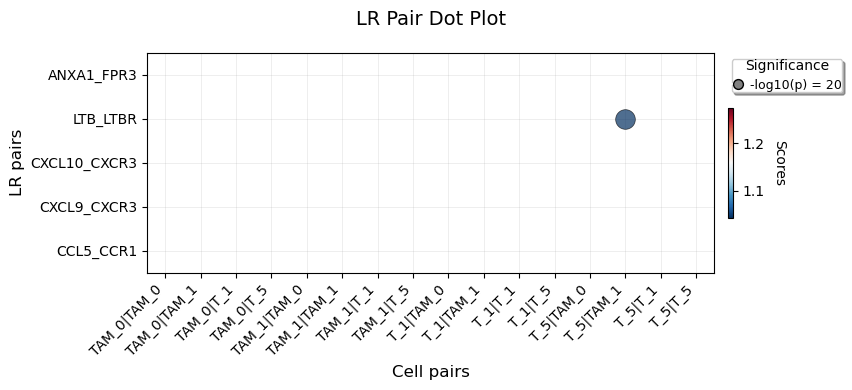

In [25]:
scores = interaction_scores.copy()
scores = significant_means.copy()

save_file_name = None
save_file_name = f"{output_dir}/LR_pair_dotplot.pdf"
LR_pair_dotplot(scores, pvals, save_file_name = save_file_name)
